# 01 - EDA con esquema actual

Este notebook documenta el dataset de startups unicornio usando el esquema vigente del proyecto.  
El target es `valuation_usd` y las variables operativas son `funding_usd`, `year_founded`, `company_age`, `industry`, `country` y `continent`, junto con features derivadas para modelado.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if (ROOT / "backend").exists():
    BACKEND = ROOT / "backend"
else:
    BACKEND = ROOT

if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))

import json
import warnings
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import load_config, resolve_path
from src.data.load import (
    build_and_save_processed_dataset,
    build_features,
    get_feature_columns,
    load_processed_dataset,
    load_raw_dataset,
    prepare_modeling_frame,
)

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="Set2")
config = load_config()
feature_cols = get_feature_columns()
target_col = config["project"]["target"]
print(f"Backend path: {BACKEND}")
print(f"Target actual: {target_col}")
print(f"Features actuales: {feature_cols}")


Backend path: C:\Users\usuario\Desktop\ProjectsF5\proyecto4-grupo4\backend
Target actual: valuation_usd
Features actuales: ['year_founded', 'log_funding_usd', 'funding_velocity', 'funding_vs_industry', 'company_age', 'industry', 'country', 'continent']


## 1. Carga de datos crudos y procesados

Se parte del CSV crudo y se reconstruye el dataset procesado con las funciones del backend, para asegurar que el notebook y la API usan la misma lógica.


In [2]:
raw = load_raw_dataset()
processed_path = build_and_save_processed_dataset()
featured = load_processed_dataset()

print(f"Raw shape: {raw.shape}")
print(f"Processed shape: {featured.shape}")
print(f"Dataset procesado guardado en: {processed_path}")
raw.head()


Raw shape: (1074, 10)
Processed shape: (1074, 20)
Dataset procesado guardado en: C:\Users\usuario\Desktop\ProjectsF5\proyecto4-grupo4\backend\data\processed\dataset.pkl


,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."


## 2. Esquema actual del dataset

Estas son las columnas usadas o generadas por el pipeline actual. El contrato productivo queda centrado en las variables actuales de fundacion, financiacion, edad, industria, pais y continente.


In [3]:
schema = pd.DataFrame({
    "column": featured.columns,
    "dtype": [str(dtype) for dtype in featured.dtypes],
    "missing": featured.isna().sum().values,
    "missing_pct": (featured.isna().mean().values * 100).round(2),
})
schema[schema["column"].isin([target_col, "funding_usd", "year_founded", "company_age", "industry", "country", "continent", "log_funding_usd", "funding_velocity", "funding_vs_industry"])]


,column,dtype,missing,missing_pct
10,valuation_usd,float64,0,0.00
11,funding_usd,float64,12,1.12
12,year_founded,int64,0,0.00
13,company_age,int64,0,0.00
14,industry,object,0,0.00
15,country,object,0,0.00
16,continent,object,0,0.00
17,log_funding_usd,float64,12,1.12
18,funding_velocity,float64,12,1.12
19,funding_vs_industry,float64,12,1.12


## 3. Calidad de datos para regresión

Validamos nulos, duplicados y cobertura de las columnas necesarias para el modelo.


In [4]:
required = [target_col, "funding_usd", "year_founded", "company_age", "industry", "country", "continent"]
quality = pd.DataFrame({
    "check": ["required_columns", "duplicate_rows", "model_rows", "target_positive", "funding_non_negative"],
    "value": [
        all(col in featured.columns for col in required),
        int(featured.duplicated().sum()),
        int(prepare_modeling_frame(featured)[0].shape[0]),
        bool((featured[target_col].dropna() > 0).all()),
        bool((featured["funding_usd"].dropna() >= 0).all()),
    ],
})
quality


,check,value
0,required_columns,True
1,duplicate_rows,0
2,model_rows,1062
3,target_positive,True
4,funding_non_negative,True


## 4. Distribución del target `valuation_usd`

La variable objetivo está muy sesgada hacia la derecha: hay muchas empresas alrededor de 1-2B USD y pocas compañías extremadamente altas.


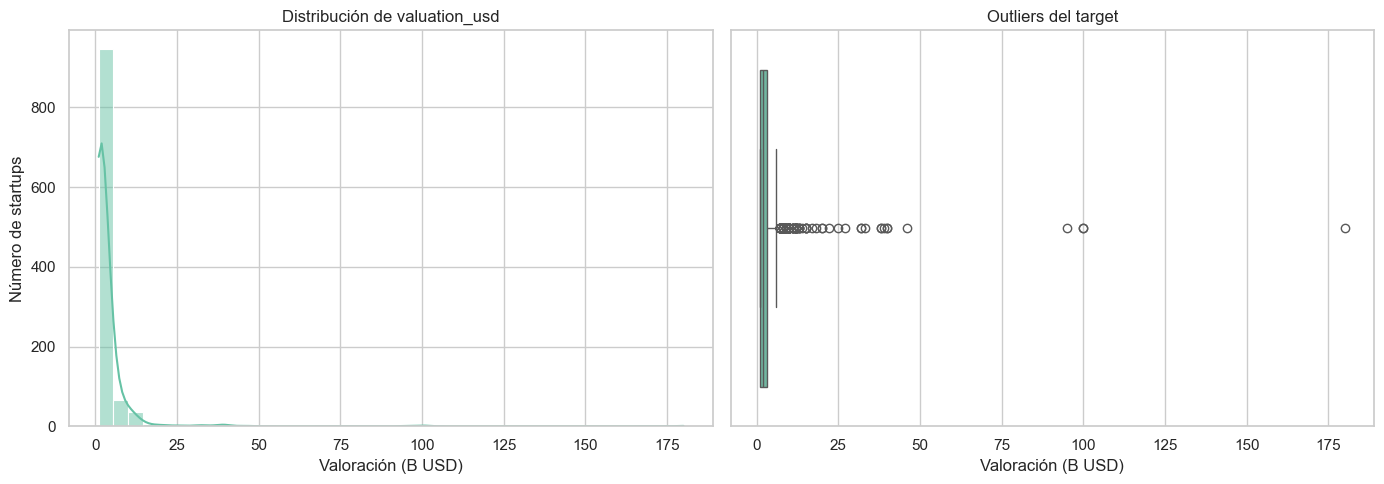

,valuation_usd
count,1.074000e+03
mean,3.455307e+09
std,8.547022e+09
min,1.000000e+09
50%,2.000000e+09
75%,3.000000e+09
90%,6.000000e+09
95%,1.000000e+10
99%,3.227000e+10
max,1.800000e+11


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(featured[target_col] / 1e9, bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribución de valuation_usd")
axes[0].set_xlabel("Valoración (B USD)")
axes[0].set_ylabel("Número de startups")

sns.boxplot(x=featured[target_col] / 1e9, ax=axes[1])
axes[1].set_title("Outliers del target")
axes[1].set_xlabel("Valoración (B USD)")
plt.tight_layout()
plt.show()

featured[target_col].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("valuation_usd")


## 5. Relación entre funding y valoración

`funding_usd` no explica todo el target, pero sí aporta señal. Usamos escala logarítmica para poder ver mejor empresas pequeñas y grandes en el mismo gráfico.


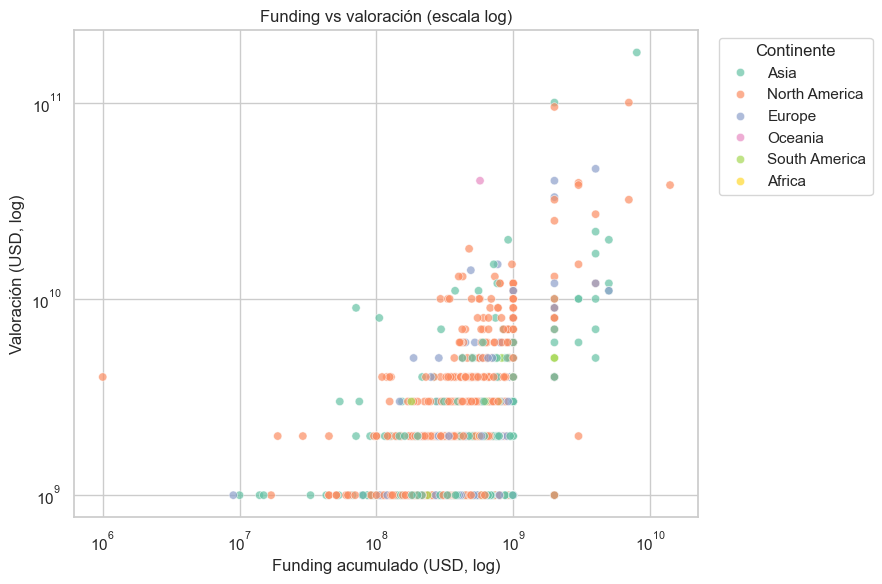

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=featured,
    x="funding_usd",
    y=target_col,
    hue="continent",
    alpha=0.7,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Funding vs valoración (escala log)")
ax.set_xlabel("Funding acumulado (USD, log)")
ax.set_ylabel("Valoración (USD, log)")
plt.legend(title="Continente", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 6. Valoración por industria, país y continente

Estas variables categóricas forman parte del contrato actual del frontend y de la API.


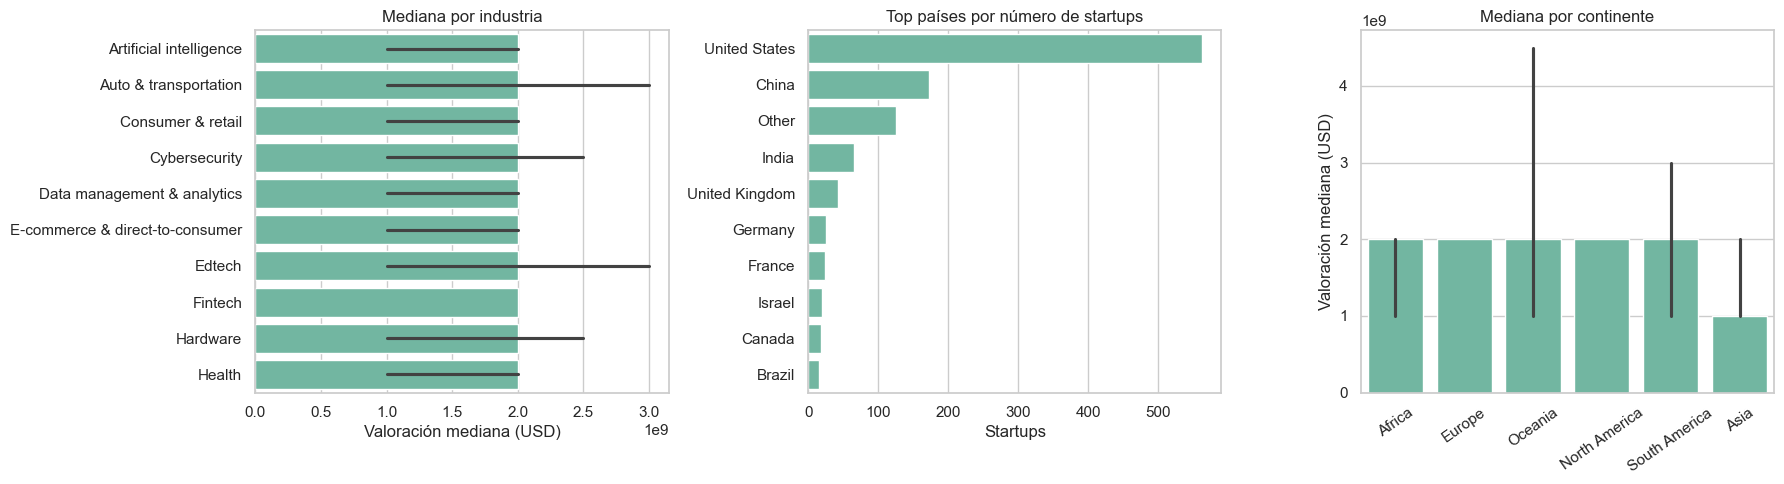

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

industry_order = featured.groupby("industry")[target_col].median().sort_values(ascending=False).head(10).index
sns.barplot(data=featured[featured["industry"].isin(industry_order)], y="industry", x=target_col, estimator="median", order=industry_order, ax=axes[0])
axes[0].set_title("Mediana por industria")
axes[0].set_xlabel("Valoración mediana (USD)")
axes[0].set_ylabel("")

country_counts = featured["country"].value_counts().head(10)
sns.barplot(x=country_counts.values, y=country_counts.index, ax=axes[1])
axes[1].set_title("Top países por número de startups")
axes[1].set_xlabel("Startups")
axes[1].set_ylabel("")

continent_order = featured.groupby("continent")[target_col].median().sort_values(ascending=False).index
sns.barplot(data=featured, x="continent", y=target_col, estimator="median", order=continent_order, ax=axes[2])
axes[2].set_title("Mediana por continente")
axes[2].set_xlabel("")
axes[2].set_ylabel("Valoración mediana (USD)")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


## 7. Features derivadas actuales

El modelo no consume directamente el texto monetario crudo. El pipeline genera variables numéricas diseñadas para aportar señal de intensidad y escala de financiación.


In [8]:
engineered = ["log_funding_usd", "funding_velocity", "funding_vs_industry", "company_age", "year_founded", target_col]
featured[engineered].describe().T


,count,mean,std,min,25%,50%,75%,max
log_funding_usd,1062.0,1.971599e+01,1.052731e+00,0.000000e+00,1.922268e+01,1.972901e+01,2.022774e+01,2.336232e+01
funding_velocity,1062.0,4.572541e+07,6.438208e+07,0.000000e+00,1.853224e+07,2.990455e+07,5.019231e+07,1.272727e+09
funding_vs_industry,1062.0,1.445750e+00,1.999785e+00,0.000000e+00,6.139206e-01,1.000000e+00,1.612796e+00,3.244496e+01
company_age,1074.0,1.310428e+01,5.698573e+00,5.000000e+00,1.000000e+01,1.200000e+01,1.500000e+01,1.070000e+02
year_founded,1074.0,2.012896e+03,5.698573e+00,1.919000e+03,2.011000e+03,2.014000e+03,2.016000e+03,2.021000e+03
valuation_usd,1074.0,3.455307e+09,8.547022e+09,1.000000e+09,1.000000e+09,2.000000e+09,3.000000e+09,1.800000e+11


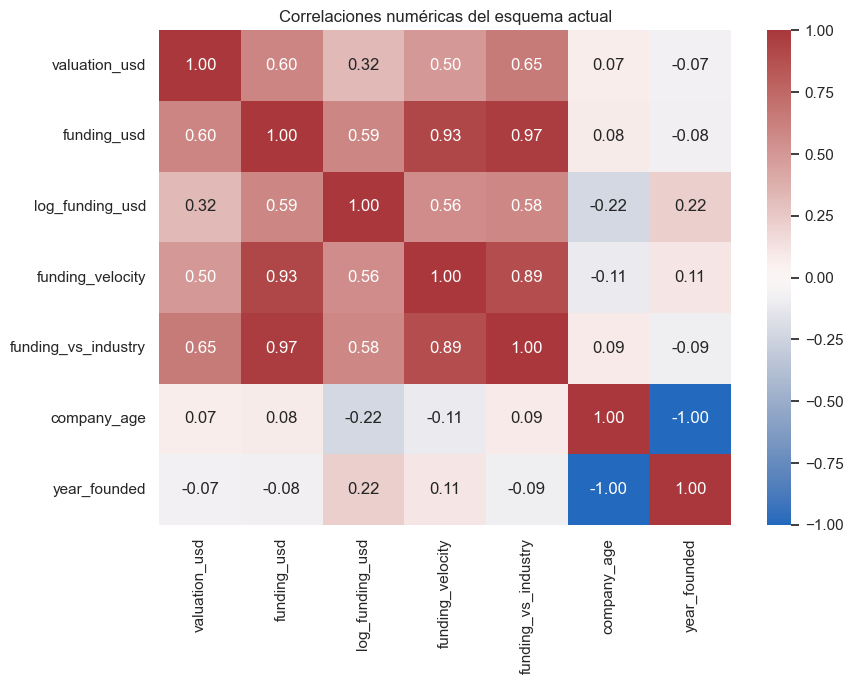

In [9]:
corr = featured[[target_col, "funding_usd", "log_funding_usd", "funding_velocity", "funding_vs_industry", "company_age", "year_founded"]].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlaciones numéricas del esquema actual")
plt.tight_layout()
plt.show()


## 8. Limitaciones del modelo y del dataset

- La distribución de `valuation_usd` tiene una cola alta muy marcada: empresas como decacornios concentran gran parte del error.
- Las variables disponibles son útiles para una estimación inicial, pero no capturan información crítica como ingresos, crecimiento, rentabilidad, rondas históricas o momento macroeconómico.
- La relación entre funding y valoración no es puramente lineal; por eso el pipeline usa transformaciones logarítmicas y modelos ensemble.
- El dataset representa una foto histórica de unicornios; no garantiza que el comportamiento de mercado futuro sea igual.
- El feedback recogido por la aplicación debe usarse para monitorizar errores reales y preparar reentrenamientos futuros.
